# RNN-Based Text Generation Using Tiny Shakespeare

**Task:** Dataset Preparation and Next-Word Sequence Generation  


In [ ]:
!pip install -q datasets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import re

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [ ]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)

print("Status code:", response.status_code)

text = response.text

print("Total characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Status code: 200
Total characters: 1115394

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods

In [ ]:
!pip install -q huggingface_hub


In [ ]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="karpathy/tiny_shakespeare",
    filename="tiny_shakespeare.py",
    repo_type="dataset"
)

print(file_path)

tiny_shakespeare.py:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--karpathy--tiny_shakespeare/snapshots/c7a7ff3e41cda4f190ec575d180e764eb7f7f4ba/tiny_shakespeare.py


In [ ]:
print("Data type:", type(text))
print("Total characters:", len(text))

print("\nSample text:")
print(text[:2000])

Data type: <class 'str'>
Total characters: 1115394

Sample text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods kn

In [ ]:
text = text.lower()

print(text[:1000])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for the gods know i
speak this in hunger for bread, not in thirst for revenge.



In [ ]:
words = text.split()

print("Total number of words:", len(words))

print("\nFirst 50 words:")
print(words[:50])

Total number of words: 202651

First 50 words:
['first', 'citizen:', 'before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.', 'all:', 'speak,', 'speak.', 'first', 'citizen:', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish?', 'all:', 'resolved.', 'resolved.', 'first', 'citizen:', 'first,', 'you', 'know', 'caius', 'marcius', 'is', 'chief', 'enemy', 'to', 'the', 'people.', 'all:', 'we', "know't,", 'we', "know't.", 'first', 'citizen:', 'let', 'us']


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

print("Vocabulary size:", vocab_size)

print("\nFirst 20 vocabulary words:")
print(list(word_index.items())[:20])

Vocabulary size: 12633

First 20 vocabulary words:
[('the', 1), ('and', 2), ('to', 3), ('i', 4), ('of', 5), ('you', 6), ('my', 7), ('a', 8), ('that', 9), ('in', 10), ('is', 11), ('not', 12), ('for', 13), ('with', 14), ('me', 15), ('it', 16), ('be', 17), ('your', 18), ('his', 19), ('but', 20)]


In [ ]:
sequences = tokenizer.texts_to_sequences([text])[0]

print("First 50 token IDs:")
print(sequences[:50])

First 50 token IDs:
[88, 269, 139, 35, 969, 143, 668, 127, 15, 102, 33, 102, 102, 88, 269, 6, 40, 33, 1268, 350, 3, 199, 63, 3, 3332, 33, 1268, 1268, 88, 269, 88, 6, 91, 1141, 231, 11, 2274, 580, 3, 1, 305, 33, 35, 2555, 35, 2555, 88, 269, 70, 78]


In [ ]:
seq_length = 10

input_sequences = []

for i in range(seq_length, len(sequences)):
    sequence = sequences[i-seq_length:i+1]
    input_sequences.append(sequence)

print("Number of sequences:", len(input_sequences))

Number of sequences: 204079


In [ ]:
import numpy as np

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (204079, 10)
Target shape: (204079,)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(
    X,
    maxlen=seq_length,
    padding="pre"
)

print("Padded input shape:", X_padded.shape)

Padded input shape: (204079, 10)


In [ ]:
split_index = int(0.8 * len(X_padded))

X_train = X_padded[:split_index]
y_train = y[:split_index]

X_val = X_padded[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining input shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nValidation input shape:", X_val.shape)
print("Validation target shape:", y_val.shape)

Training samples: 163263
Validation samples: 40816

Training input shape: (163263, 10)
Training target shape: (163263,)

Validation input shape: (40816, 10)
Validation target shape: (40816,)


##IMPLEMENTING THE RNN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Create the RNN model
model = Sequential([

    # Define input shape
    Input(shape=(seq_length,)),

    # Convert word IDs into dense vectors
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Learn sequential dependencies
    SimpleRNN(128),

    # Predict the next word
    Dense(vocab_size, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 128)        │     1,617,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,629,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,279,577 (12.51 MB)

 Trainable params: 3,279,577 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

##RNN Model Training

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.0468 - loss: 6.7367 - val_accuracy: 0.0651 - val_loss: 6.7595
Epoch 2/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0868 - loss: 6.0742 - val_accuracy: 0.0806 - val_loss: 6.6738
Epoch 3/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1028 - loss: 5.7163 - val_accuracy: 0.0865 - val_loss: 6.7362
Epoch 4/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1158 - loss: 5.4202 - val_accuracy: 0.0850 - val_loss: 6.8262
Epoch 5/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1297 - loss: 5.1474 - val_accuracy: 0.0825 - val_loss: 6.9314
Epoch 6/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1446 - loss: 4.8949 - val_accuracy: 0.0829 - val_loss: 7.1098
Epoch 7/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1647 - loss: 4.6513 - val_accuracy: 0.0798 - val_loss: 7.2228
Epoch 8/10
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1888 - loss: 4.4167 -

In [ ]:
# Get final training and validation metrics

final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Final Training Accuracy :", final_train_accuracy)
print("Final Validation Accuracy :", final_val_accuracy)

print("Final Training Loss :", final_train_loss)
print("Final Validation Loss :", final_val_loss)

Final Training Accuracy : 0.24608759582042694
Final Validation Accuracy : 0.07212857902050018
Final Training Loss : 3.9798147678375244
Final Validation Loss : 7.616437911987305


In [ ]:
print("Final Training Accuracy   : {:.2f}%".format(final_train_accuracy * 100))
print("Final Validation Accuracy : {:.2f}%".format(final_val_accuracy * 100))

print("Final Training Loss       : {:.4f}".format(final_train_loss))
print("Final Validation Loss     : {:.4f}".format(final_val_loss))

Final Training Accuracy   : 24.61%
Final Validation Accuracy : 7.21%
Final Training Loss       : 3.9798
Final Validation Loss     : 7.6164


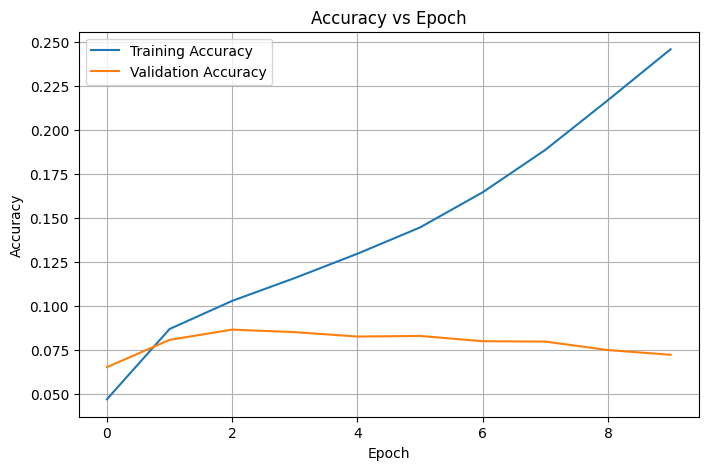

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

**Training:**
The RNN model is trained using the prepared training sequences for 10 epochs. During training, the model learns the relationship between the previous words in a sequence and the corresponding next word.

**Accuracy:** Training accuracy represents the proportion of correctly predicted next words on the training dataset, while validation accuracy represents the proportion of correctly predicted next words on the validation dataset.

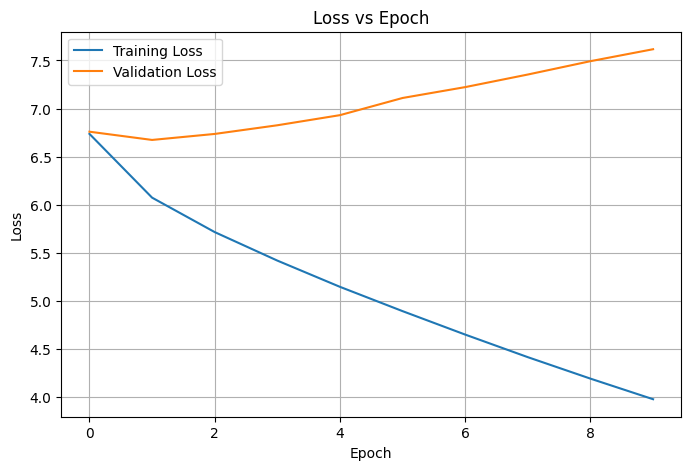

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

**Validation:**
The validation dataset is used after each training epoch to evaluate the model's performance on unseen sequences. Validation accuracy and validation loss are recorded to monitor the generalization performance of the model.

**Loss:** Loss represents the difference between the predicted probability distribution and the actual next word. A lower loss generally indicates that the model's predictions are closer to the expected target.

##Text Generation

The trained RNN model was used to generate text by providing different seed words or sentences as input. The seed text was converted into integer sequences using the trained tokenizer and padded to the required sequence length. The model then repeatedly predicted the next word, which was appended to the existing text to generate a longer sequence.


In [ ]:
# Reverse vocabulary: ID -> word
reverse_word_index = {index: word for word, index in word_index.items()}


def generate_text(seed_text, next_words=20):
    """
    Generate text by repeatedly predicting the next word.
    """

    generated_text = seed_text.lower()

    for _ in range(next_words):

        # Convert seed text into integer sequence
        token_list = tokenizer.texts_to_sequences([generated_text])[0]

        # Keep only the last seq_length words
        token_list = token_list[-seq_length:]

        # Pad sequence
        token_list = np.array(
            pad_sequences(
                [token_list],
                maxlen=seq_length,
                padding="pre"
            )
        )

        # Predict next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_id = np.argmax(predicted_probabilities, axis=-1)[0]

        # Convert ID back to word
        predicted_word = reverse_word_index.get(
            predicted_word_id,
            ""
        )

        # Stop if no valid word is predicted
        if predicted_word == "":
            break

        # Add predicted word to generated text
        generated_text += " " + predicted_word

    return generated_text

The generated text varied depending on the seed input. The model was able to produce word sequences that showed patterns learned from the training data. Some generated sequences were contextually relevant and showed reasonable coherence, while others contained repetitions or grammatically incorrect combinations. This indicates that the Simple RNN learned statistical relationships between words, but its ability to maintain long-term context was limited.


In [ ]:
# Generate text using different seed inputs

seed_inputs = [
    "the king",
    "i am",
    "my lord",
    "this is",
    "when the"
]

for seed in seed_inputs:
    generated = generate_text(seed, next_words=20)

    print("\nSeed:", seed)
    print("Generated Text:")
    print(generated)
    print("-" * 80)


Seed: the king
Generated Text:
the king is dead and all the world is not the dead and by the bright of war i have not the
--------------------------------------------------------------------------------

Seed: i am
Generated Text:
i am ready to be revenged on him that i have not to the crown king richard ii we shall be satisfied
--------------------------------------------------------------------------------

Seed: my lord
Generated Text:
my lord wherein i not speak of thy speech and i have heard the face of him first servingman what is the
--------------------------------------------------------------------------------

Seed: this is
Generated Text:
this is death within the world that slew me gaunt in this my tongue is my lord king richard iii what is
--------------------------------------------------------------------------------

Seed: when the
Generated Text:
when the nobles was not to the court cupboard i have been in the house of york that i have done to
------------------------

| Seed         | Observation                                                                                                                                                                                       |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **the king** | The model continues with words related to death, war, and kings, showing reasonable contextual relevance. However, some phrases are grammatically inconsistent.                                   |
| **i am**     | The generated text maintains a dialogue-like style and includes words such as *revenged*, *crown*, *king*, and *satisfied*, which fit the Shakespearean context.                                  |
| **my lord**  | The continuation contains dialogue-related words such as *thy*, *speech*, *heard*, and *servingman*. The output is somewhat relevant but has incomplete grammatical structure.                    |
| **this is**  | The model generates words associated with death, speech, and King Richard, showing that it has learned patterns from the Shakespeare corpus. Some word combinations are unnatural.                |
| **when the** | The generated sequence contains words related to nobles, court, house, York, and actions, indicating contextual patterns from the training data. Grammar and sentence structure are inconsistent. |


The trained RNN model successfully generated multiple text samples using different seed inputs. The generated samples were compared based on coherence, contextual relevance, grammar, and repetition. The experiment demonstrated the use of an RNN for next-word prediction and sequential text generation.
